# 8. Error Handling

## 8.0x. Comprehension & Retention Strategy 

### 8.0x.0. Overview

For this Chapter to experiment with comprehension and retention of the material, I will explore covering the chapter with some guided prompts. Breaking down the prompts into
- Before Reading
- During
- After

The idea is to break down a reading block into per sub-section and further into paragraphs is the information is too dense.

Question is whether it would be appropriate to skim through the whole chapter first before doing a second thorough read. I'm finding myself in that approach. Then the next chapter (Chapter 9) we can see if skimming the materail first has a benefit.

Thinking whether it would also be good to state assumptions about the chapter before skimming and then be able to validate if the assummptions were true.

Also thinking it would be good to take note of questions raised during the skimming and parts that I think need special/close attention to once we do a second read.

The prompts are inspired by some questions/prompts suggested by different LLMs. Refer to links below
- [ChatGPT](https://chatgpt.com/c/6a0d72f9-66b8-83ea-b983-c2eb4f529cc8)
- [Gemini Pro](https://gemini.google.com/app/7523f072b0032685)
- [Claude Opus 4.6](https://claude.ai/share/58fe2e3f-0294-4848-90f4-e70021b183c4)

### 8.0x.1. Before Reading

#### 8.0x.1.0. Intro

Here are some good prompts that would be good for the _Before Reading Phase_.

- _Why do I think this Chapter important?_
- _What do I think I already know about this Chapter?_
- _What do I think I will learn in this Chapter?_

I think those questions suffice for now. Might update later.

#### 8.0x.0.1. Why Do I Think This Chapter Important?

I think **Error Handling** is an important chapter to get into because
- We get to think about invalid states that an application might be in preemptively. Thss makes our app
  less buggy and more reliable because we address potential error paths up-front instead of waiting to
  be supprised later in production.
- Makes it easier for a developer to debug the an application faster because a lot of the data and
  context has been already been baked into a error when it thrown.

#### 8.0x.0.2. What Do I Think I Already Know About This Chapter?

Not too much, to be honest. Coming from a python background where use use raise and throw `exceptions` and I think rust prefers returning `errors` and allowing callers to decide whether to crash the program or return the error as a value. Have watched some videos on exceptions vs error values, but not sure i've completely grokked the difference.<br/>
One thing I will say if I recall what _The Book_ says about this topic is that there are basically 2 
types of errors
1. Recoverable Errors
2. Unrecoverable Errors

And you want to use different approaches when it comes to each. And it is important to make sure we handle all fallible operations appropriately and not just call `unwrap()` on them.

#### 8.0x.0.2. What Do I Think I Will Learn From This Chapter?

- Right now the major thing that comes to mind is that, so far we are just returning `StatusCode::INTERNAL_SERVER_ERROR` for the situation where either a `sqlx` operation or `reqwest`
operation fails. We probably want to handle this better so that we return more descriptive errors incase of either of the failures. <br/>
- We might also learn how to recover from recoverables failures in our application.

### 8.0x.2. During Reading

During skimming and when we re-read more deeply these are some guiding questions i'm thinking.

_Skimming Phase_<br/>
- _What are some concepts/ideas that standout and why?_
    - Is it because the idea/concept feels interesting or challengeing
    - Why is it interesting or challenging to you?

_Deep Dive Phase_
- _Can I **summarize** and **explain** what I've read in my own words without looking?_
   - Internalize key definitions/ code snippets that I want to memorize and know by
     heart.
    - Summarize in a sentence or less
    - How would I explain this concept to a beginner
- _How does this connect to or challenge, something I already understand?_
    - What are some of my assumptions that were true vs were not. 
- _Am I still tracking with the author, or did my mind just wander?_
    - Where did my mind go and what is most distracting? 

### 8.0x.3. After Reading

Some question in this phase are
- _What was the main idea/mechanism/argument and What were the 3-5 most important
  ideas/supporting details?_
- _Where does my understanding break down, what were the more challenging concepts and
  ideas to wrap my head around & how to I get better?_
- _Where and how would I actually use this?_

### 8.0x.4. Summary

These are a lot of guiding/prompts but hopefully we'll have refined a lot of them by the time we are done with the chapter

## 8.0. Overview

### 8.0.0. Skimming: What did you notice and why? Any Questions

_**What?**_<br/>
I like the questions the author rises right of the bat;
1. How do errors fit within the broader architecture of our application?
2. **What does a _good_ error look like?**
3. **Who are errors for?**
4. Should we use libraries for this and which ones?

_**Why?**_<br/>
I thinks these are good questions because that means by the end of the chapter one a key question like;
> _What does good error handling look like for all interested/affected parties?_

Would be good to revisit this questions and see if it was answered satisfactorily. Like out of 10 how satisfied were you
with the answer? <br/>
1 - Not satisfied at all, 10 Very very satisfied.


_**Questions?**_<br/>
None

_**Reflections & Answers**_ <br/>
After skimming through the book, how satisfied am I with how the book answered this question:
> _What does good error hanlding look lie for all interested parties?_

Honestly I would say around a 6.5 - 7. I feel like a got a general oveview and lay of the land. Might have to suppliment with  
extra material to feel satisfied and confident about what good error handling should look like upto the tracling layer.

I feel like I would have wanted a bit more on how errors and tracing are connected.

## 8.1. What Is The Purpose Of Errors?

### 8.1.0 Overview

##### 8.1.1.1.0. Deep Dive: Summarize, ELI5, Connect

_**Summarize**_  
Here we walk through 2 examples that help demonstrate the core idea around error handing for the main stakeholders
- Operators - These are the developers implementating a library or writing an application
- Users - These are the users of your application or library


Example 1 uses the `store_token` method in `src/routes/subscriptions.rs` that we can in `subscribe`.  
It was implemented as follows;
```Rust
//! src/routes/subscriptions.rs
// [...]

#[tracing::instrument([...])]
pub async fn subscribe([...]) -> HttpResponse {
    // [...]
    if store_token(&mut transaction, &subscription_token, subscriber_id)
        .await
        .is_err 
    {
        return HttpResponse::InternalServerError().finish();
    }
    // [...]
}


#[tracing::instrument([...])]
async fn store_token(
    transaction: &mut Transaction<'_, Postgres>,
    subscription_token: &str,
    subscriber_id: Uuid,
) -> Result<(), sqlx::Error> {
    let query = sqlx::query!(
        r#"
            INSERT INTO subscription_tokens (subscription_token, subscriber_id)
            VALUES ($1, $2)
        "#,
        subscription_token,
        subscriber_id,
    );

    // Fallibale operation
    transaction.execute(query)
        .await
        .map_err(|e| {
            tracing::error!("Failed while executing store token query: {}", e);
            e
        })?;
    Ok(())
}
```

In example 2 we use the form validation `match form.0.try_into()` snippet where we are validating user input (username and email) ensuring  
they were parsed appropriately into our custom types otherwise we raise a `BadRequest` status code.
```Rust
//! src/routes/subscriptions.rs
// [...]

impl TryFrom<FormData> for NewSubscriber {
    type Error = String;
    fn try_from(val: FormData) -> Result<Self, Self::Error> {
        let username = SubscriberUsername::parse(val.username)?;
        let email = SubscriberEmail::parse(val.email)?;
        Ok(Self { username, email })
    }
}

#[tracing::instrument([...])]
pub async fn subscribe(
    form: web::Form<FormData>,
    db_pool: web::Data<PgPool>,
    email_client: web::Data<EmailClient>,
    base_url: web::Data<ApplicationBaseUrl>,
) -> HttpResponse {
    let new_subscriber = match form.0.try_into() {
        Ok(form) => form,
        Err(_) =>  return HttpResponse::BadRequest().finish(),
    };

    // [...]
}
```

One is definitely an internal error given by the fact that we are actually returning an `InternalServerError` response.  
Meaning this one needs to be handled internally by the engineering team.

The other is a validation error that is client/user facing we return a `BadRequest` response. This one a user/client can
fix by correcting their inputs to the application.

### 8.1.1. Internal Errors

#### 8.1.1.1.0 Skimming: What did you notice and why? Any Questions

_**What?**_<br/>
I like the questions the author rises right of the bat;
1. How do errors fit within the broader architecture of our application?
2. **What does a _good_ error look like?**
3. **Who are errors for?**
4. Should we use libraries for this and which ones?

_**Why?**_<br/>
I thinks these are good questions because that means by the end of the chapter one a key question like;
> _What does good error handling look like for all interested/affected parties?_

Would be good to revisit this quiestion and see if it was answered satisfactorily. Like out of 10 how satisfied were you
with the answer? <br/>
1 - Not satisfied at all, 10 Very very satisfied.


_**Questions?**_<br/>
None

#### 8.1.1.1. Enable The Caller To React

##### 8.1.1.1.0 Skimming: What did you notice and why? Any Questions

_**What?**_<br/>
The `sqlx::Error` enum.

_**Why?**_<br/>
Someone took the time to map out possible error states when executing an sqlx query. Key take away is the attention to detail and meticulousness it must 
have took to map this


_**Questions?**_<br/>
- Curious about the distribution of errors across the variants of the `sqlx::Error` enums. Are there some errors that are more common that others?
- Wonder if there's any telemetry that is collected within the rust language itself that informs what the compiler optimizes? Sure this is a rabbit hole

##### 8.1.1.1.0. Deep Dive: Summarize, ELI5, Connect

_**Summary.**_  
- Because operations can fail in _multiple different ways_ we might want to respond differently depending on what happened.

_**ELI 5.**_

Looking at the `store_token` operation more closely, if it transaction execution fails there might be a couple of reasons
- Network failure i.e. took to long to execute query
- The query had an issue in that maybe we violated some DB constraint i.e. the `subscription_token` wasn't unique

Looking at the skeleton of `sqlx::Error`, the error type for `execute`, we see some possible errors that might occur

```Rust
//! sqlx-core/src/errors.rs

pub enum Error {
    Configuration(/* */),
    Database(/* */),
    Io(/* */),
    Tls(/* */),
    Protocol(/* */),
    RowNotFound,
    TypeNotFound {/* */},
    ColumnIndexOutOfBound {/* */},
    ColumnNotFound(/* */),
    ColumnDecode {/* */},
    Decode(/* */),
    PoolTimedOut,
    PoolClosed,
    WorkerCrashed,
    Migrate(/* */),
}

```
`sqlx::Error` is implemented as an enum to allow operators(users) to match returned error and behave _differently_ depending on the  
underlying failue modes. For example we might want to return a `PoolTimedOut` while we probably want to give up on a `ColumnNotFound`

Right now we don't have the appropriate mechanism to branch based on the error scenario.



#### 8.1.1.1. Help An Operator To Trouble Shoot.

##### 8.1.1.1.0. Deep Dive: Summarize, ELI5, Connect

_**Summarize**_  
We need enough information and context about errors to be able to troubleshoot efficiently and effectively when they occur.

_**ELI 5**_
Currently we are doing a `tracing::error!` log in `store_token` that helps report a failure. We can then inspect the logs when  
investigation an issue with the `transaction`
```Rust
#[tracing::instrument([...])]
async fn store_token([...]) -> Result<(), sqlx::Error> {
    // [...]
    transaction.execute(query)
        .await
        .map_err(|e| {
            tracing::error!("Failed to execute store token query: {:?}", e);
            e
        })?;
    // [...]
}
```

_**Connect**_  
For `sqlx::Error` we are both a user/client and operator/implementor.

As a user/client `sqlx::Error` provides us with variants we can use to control how the application responds. And the errors returned just give use  
enough information to correct our implementation or retry.

As operators/implementators we can then write custom types, methods, or wrappers that extend what sqlx provides for ourselves as operators or the end users.

### 8.1.2. Errors At The Edge.

#### 8.1.2.1 Help A User To Troubleshoot

##### 8.1.2.1.0 Skimming: What did you notice and why? Any Questions

_**What?**_<br/>
**Transient** _meaning_: Lasting only for a short time, impermanent, or temporary.<br/>
So _transient errors_ mean errors that last only for a short while and can be retried.

_**Why?**_<br/>
Have seen the word transient a couple of times in a programming context. Now I know it means short lived.

Note the difference between _transient_ and _transitive_

_**Questions?**_<br/>
None

##### 8.1.1.1.0. Deep Dive: Summarize, ELI5, Connect

_**Summarize**_  
Users/Clients of our APIs need a _signal_ when a failure mode is encountered.  
We need to provide the user with the right and approriate ammount of information required for them to know if 
1. This is an issue they need to resolve on their end
2. This is an issue being resolved on the operator side  

Without leaking implemeantion details

_**ELI 5**_  

A user facing the `InternalServerError` raised by the `store_token` at most only needs to be informed to come back later when the service back up again  
without leaking what is in the realm of the operator. We do this currently by simply returning the `HttpResponse::InternalServerError.finish()`.
```Rust
//! src/routes/subscriptions.rs
// [...]

pub async fn subscribe(/* */) -> HttpResponse {
    // [...]
    if store_token(&mut transaction, &subscription_token, subscriber_id)
        .await
        .is_err()
    {
        return HttpResponse::InternalServerError().finish()   
    }
}
```

A user facing the `BadRequest` error raised by validation of the form input `FormData` would probably want to know what they need to fix on their end  
for their input data to be valid. Currently though, we are just returning a `BadRequst` status code that is not as informative.
```Rust

//! src/routes/subscriptions.rs
// [...]

pub async fn subscribe(/* */) -> HttpResponse {
    // [...]
    let new_subsciber = match form.0.try_into() {
        Ok(form) => form,
        Error(_) => return HttpResponse::BadRequest().finish()
    };
}
```
Internally though we are logging via `tracing::error!` in the relavant domains of the email and username validation. Below is the `src/domain/subscription_email.rs`
```Rust
//! src/domain/subscription_email.rs
// [...]

impl SubscriptionEmail {
    pub fn parse(s: String) -> Result<Self, String> {
        if s.validate_email() {
            Ok(Self(s))
        } else {
            Err(format!("{} is not a valid subscriber email.", s))
        }
    }
}
```

Good for the operator (us), not so good for the user. To fix this we need to populate the response body associated with the `BadRequest()` status we return for the user
to know what to do.

_**Connect**_  

### 8.1.3. Summary

##### 8.1.2.1.0 Skimming: What did you notice and why? Any Questions

_**What?**_<br/>

Rust conf talk by Jane Lusby [Error Handling Isn't All About Errors]().

Liked the error handling matrix

$$
\begin{array}{c|c|c}
\hline
    & \textsf{Internal} & \textsf{At the edge} \\
\hline
\textsf{Control Flow} & \textsf{Types} & \textsf{Status Code } \\
\textsf{Reporting} & \textsf{Logs} & \textsf{Response Body}\\
\hline
\end{array}
$$


_**Why?**_<br/>
The author says we should listen to the talk immediately. Seems like it's super talk.

Biggest takeaway from the talk is, that there is a divide between
- library errors that should be very descriptive informing where things failed and why ( use `thiserror`).
- application errors that are communicated while application is running? ( use `anyhow`).

 Still not super clear. Worth revisiting.

_**Questions?**_<br/>
None

##### 8.1.1.1.0. Deep Dive: Summarize, ELI5, Connect

_**Summarize**_  
In understanding the best way to handle errors we need to understand;
1. Intent the purpose
    - Control Flow and/or
    - Reporting
2. Audience
    - Internal Operators (working on the implemetation) and/or
    - Users - users of the implementation
3. Techniques available
    - Types, methods, fields
    - Logs/Traces
    - StatusCodes
    - Response Bodies

This is where the matrix the author provides gives quite a good summary of how to think about errors on a high level.  
I use different semantics for my own internalization.  
$$
\begin{array}{c|cc}
\textsf{Purpose}               & \textsf{Audience}                  &                \\
\hline
                               & \textsf{Operators/Implementators}  & \textsf{Users} \\
\hline
\textsf{Control Flow} & \textsf{Types, methods, fields}             & \textsf{StatusCodes} \\
\textsf{Reporting}    & \textsf{Logs/Tracing}                       & \textsf{ResponseBody}\\
\hline
\end{array}
$$

This is basically what we are going to unpack over this chapter.

## 8.2. Error Reporting For Operators

##### 8.1.2.1.0 Skimming: What did you notice and why? Any Questions

_**What?**_<br/>

- Reflecting on the difference between a _generic_ type and a _trait object_

Generics have to be filled in at comptime, Trait objects can only be known at runtime.

Best example I can think of is when an event calltime. 

We can know that we need a specified call time when team members or vendors need to get the office
or arrive at an event venue. We call this variable `call_time` and we'll give it a concrete time X.pm/am.

However the actuall time that team members or vendors will arrive is dynamic only to be know when they arrive.

Another good example is lets say we have a singing competition that is only elidgible to people over 16 for example.
The singing competition is generic over the competitants as long as they are over 16 years old. This will be known
by sign-up because they need to fill in some key details. However wether they can sing or not will only be know
when they open there mouth to sing in person. So;
- Contestants is _generic_ can be known with reasonble certainty at sign-up (comptime)
- Ability to sing is a _trait_ - can only be assessed at time of singing (runtime - dynamic dispatch)


_**Why?**_<br/>

Reasoning about why we need _dynamic dispatch_ of Errors as _trait objects_.

_**Questions?**_<br/>

- The books mentions that there's meant to be a `chain` method on `Error`. Curious what `Error` they mean here. Is it
  `std::error::Error` or `actix_web::error::Error`?

##### 8.1.1.1.0. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
This summary covers the _Overview_ to _Keeping Track Of The Error Root Cause_.

We are trying to answer the question can we provide an operator of our application with adequate log level reporting of a failure.  
Adequate means that they will have enough information to troubleshoot an issue quickly.

Because the focus in this section is _operators_ we use the `store_token` function as our case study. This is because when it is called  
on `subscribe` it returns a `HttpResponse::InternalServerError` and internal server errors are meant to be resolved by an operator.

To do this we
1. Write the test `subscribe_fails_if_a_fatal_database_error_occurs()` to inspect the logs returned to see if the needed information is captured in an effective manner
2. We implement the `actix_web::ResponseError` that allows us to pass along more context to our handlers
4. We implement a custom error `StoreTokenError` because we can't implement `ResponseError` on errors definied outside our application by external crates.
5. We implement `Debug` and `Display` traits on our custom `StoreTokenError` that wraps an `sqlx::Error`.
6. We update `store_token` to return the `StoreTokenError` instead of the previous plain `sqlx::Error`
7. We update our `subscribe` to return a `Result<HttpResponse, actix_web::Error>` and use a plain try operator `?` when calling `store_token` in `subscribe`

This allows us to add more context to the `subscribe` handler which previously was only returning an `InternalServerError` incase `store_token` failed. The setup now  
propagates more context to the handler so that an operator can know why an `InternalServerError` was returned and what caused it. 

We start with writing a test `subscribe_fails_if_a_fatal_database_error_occurs()` that we know causes a failure and we inspect the logs returned.

### 8.2.0. Overview

##### 8.1.1.1.0. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Here we're just implementing the test `subscribe_fails_if_a_fatal_database_error_occurs` and evaluate the returned logs.  
The test is implemented as follows;
```Rust
#[tokio::test]
async fn subscribe_fails_if_a_fatal_database_error_occurs() {
    // Arrange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";
    // Sabotaging our DB by dropping the primary key column
    sqlx::query!("ALTER TABLE subscription_tokens DROP COLUMN subscription_token;",)
        .execute(&app.db_pool)
        .await
        .expect("Failed to execute drop subscription_token column query in test");
    
    // Act
    let response = app.post_subscriptions(body.into()).await;
    
    // Assert
    assert_eq!(response.status().as_u16(), 500);
}
```

The test should pass. What we are mainly interested in are the logs. Our output is slightly different from the book because of how  
we setup our logging instrumentation.

**Ours**  

```JSON
{
  "timestamp": "2026-05-23T13:02:43.259104Z",
  "level": "ERROR",
  "fields": {
    "message": "Failed to execute store_token query: Database(PgDatabaseError { severity: Error, code: \"42703\", message: \"column \\\"subscription_token\\\" of relation \\\"subscription_tokens\\\" does not exist\", detail: None, hint: None, position: Some(Original(47)), where: None, schema: None, table: None, column: None, data_type: None, constraint: None, file: Some(\"parse_target.c\"), line: Some(1068), routine: Some(\"checkInsertTargets\") })"
  },
  "target": "zero2prod::routes::subscriptions",
  "span": {
    "subscriber_email": "lei_yin_loo@gmail.com",
    "subscriber_username": "lei yin",
    "name": "Adding a new subscriber"
  },
  "spans": [
    {
      "http.client_ip": "127.0.0.1",
      "http.flavor": "1.1",
      "http.host": "127.0.0.1:64794",
      "http.method": "POST",
      "http.route": "/{name}",
      "http.scheme": "http",
      "http.target": "/subscriptions",
      "http.user_agent": "",
      "otel.kind": "server",
      "otel.name": "POST /{name}",
      "request_id": "b0509c58-4125-4fb8-971d-aec3d5cfdb85",
      "name": "HTTP request"
    },
    {
      "subscriber_email": "lei_yin_loo@gmail.com",
      "subscriber_username": "lei yin",
      "name": "Adding a new subscriber"
    }
  ]
}
```

**The Books**  

```TXT
INFO: [HTTP REQUEST - START]
INFO: [ADDING A NEW SUBSCRIBER - START]
INFO: [SAVING NEW SUBSCRIBER DETAILS IN THE DATABASE - START]
INFO: [SAVING NEW SUBSCRIBER DETAILS IN THE DATABASE - END]
INFO: [STORE SUBSCRIPTION TOKEN IN THE DATABASE - START]
ERROR: [STORE SUBSCRIPTION TOKEN IN THE DATABASE - EVENT] Failed to execute query:
Database(PgDatabaseError {
severity: Error,
code: "42703",
message:
"column 'subscription_token' of relation
'subscription_tokens' does not exist",
...
})
target=zero2prod::routes::subscriptions
INFO: [STORE SUBSCRIPTION TOKEN IN THE DATABASE - END]
INFO: [ADDING A NEW SUBSCRIBER - END]
ERROR: [HTTP REQUEST - EVENT] Error encountered while
processing the incoming HTTP request: ""
exception.details="",
exception.message="",
target=tracing_actix_web::middleware
INFO: [HTTP REQUEST - END]
exception.details="",
exception.message="",
target=tracing_actix_web::root_span_builder,
http.status_code=500
```


The most important thing to note is that from both and especially _my_ logs we are missing some very important information on why  
we got a `500`. In the original book version we can see that we are missing key details in this section.
```TXT
ERROR: [HTTP REQUEST - EVENT] Error encountered while
processing the incoming HTTP request: ""
exception.details="",
exception.message="",
target=tracing_actix_web::middleware
INFO: [HTTP REQUEST - END]
exception.details="",
exception.message="",
target=tracing_actix_web::root_span_builder,
http.status_code=500
```

I.e. `exception.details` and `exception.message` from the `tracing_actix_web::middleware` and `tracing_actix_web::root_span_builder`  
are blank. And in our case they are entirely missing. Not even the 500, is being logged. (Something we may need to investigate separately.)

However, further up the logs we can see in both
```TXT
ERROR: [STORE SUBSCRIPTION TOKEN IN THE DATABASE - EVENT] Failed to execute query:
Database(PgDatabaseError {
severity: Error,
code: "42703",
message:
"column 'subscription_token' of relation
'subscription_tokens' does not exist",
...
})
target=zero2prod::routes::subscriptions
```
```JSON
"timestamp": "2026-05-23T13:02:43.259104Z",
"level": "ERROR",
"fields": {
"message": "Failed to execute store_token query: Database(PgDatabaseError { severity: Error, code: \"42703\", message: \"column \\\"subscription_token\\\" of relation \\\"subscription_tokens\\\" does not exist\", detail: None, hint: None, position: Some(Original(47)), where: None, schema: None, table: None, column: None, data_type: None, constraint: None, file: Some(\"parse_target.c\"), line: Some(1068), routine: Some(\"checkInsertTargets\") })"
},
"target": "zero2prod::routes::subscriptions",
```

With the key error being;
```
"column 'subscription_token' of relation
'subscription_tokens' does not exist",
```

This is ok but it would be better if we knew straight up that the cause of the `500` Internal Server Error was an issue with the database.

### 8.2.1. Keeping Track Of The Error Root Cause

##### 8.2.1.0. Deep Dive: Summarize, ELI5, Connect

##### 8.2.1.0.0. Statements/Definitions I want to remember

- Currently our handler `subscribe` is completely disregarding the propagated error from `store_token` and returning a bare `Internal Server Error`

- _Orphan Rule_ we can only implement a trait on type if either the trait or type is local to our crate. Prevents conflicts when the
  needs to distingiush which trait implementation to call. Local or one defined externally. Forbids implementing an external trait from
  an external crate on type that comes from another crate.

##### 8.2.1.0.1. Summary

So this is the general gist.
- The reason our `subscribe` handler log records does not provide any information about the underlying cause of the internal server error
  is because we are completely disregarding the error propagated by the `store_token` method
- For us to be able to propagate this error in a meaning way such that `actix_web` tracing config can provide more context on the
  underlying cause of the 500 error we need to do an error conversion to `actix_web::Error`
- For this conversion we need to implement the `ResponseError` trait on a custom error type, a wrapper around the `sqlx::Error` that we
  get from the `store_token`. This is because we cannot implement the `ResponseError` trait on `sqlx::Error` because this violates the
  orphan rule. So we need a custom type `StoreTokenError(sqlx::Error)` that we can then implement the `ResponseError` trait.
- Why do we need to implement the `ResponseError` trait in the first place? 
    - We want to do a conversion from a custom error type that we have to `actix_web::Error`. To do this we need to a `From<T>`
      trait implementation that returns a result that is most appropriate for our use case.

      The `actix_web::Error` provides a `impl<T: ResponseError + 'static> From<T> for Error` that returns an `Error` for any type that
      implements `ResponseError`. The `ResponseError` trait then as default trait methods `status_code` and `error_response` that return
      the appropriate result we need in our use case.
      ```Rust
      //! actix_web/error/error.rs
      // [...]

      // `Error` for any error that implements `ResponseError`
      impl <T: ResponseError + 'static> From<T> for Error {
          fn from(err: T) -> Error {
              Error {
                  cause: Box::new(err),
              }
          }
      }
      ```
  - Also the `ResponseError` trait provides 2 default implemantations that return `500 Internal Server Error` by default
    ```Rust
    //! actix_web/error/response_error.rs
    // [...]

    /// Errors that can generate responses.
    pub trait ResponseError: fmt::Debug + fmt::Display {

        /// Returns appropriate status code for error.
        ///
        /// A 500 Internal Server Error is used by default. If [error_response](Self::error_response) is 
        /// also implemented and does not call `self.status_code()`, then this will not be used.
        fn status_code(&self) -> StatusCode {
            StatusCode::INTERNAL_SERVER_ERROR
        }

        /// Creates full response for error
        ///
        /// By default, the generated response uses a 500 Internal Server Error status code, a
        /// `Content-Type` of `text/plain`, and the body is set to `Self`'s `Displays` impl
        fn error_response(&self) -> HttpResponse<BoxBody> {
            let mut res = HttpResponse::new(self.status_code());

            let mut buf = BytesMut::new();
            let _ = write!(helpers::MutWriter(&mut buf), "{}", self);

            let mime = mime::TEXT_PLAIN_UTF_8.try_into_value().unwrap();
            res.headers_mut().insert(header::CONTENT_TYPE, mime);

            res.set_body(BoxBody::new(buf))
        }

        downcase_get_type_id!();
    }
    ```
    What this allows us is to now more conveniently pass along our error in `store_token` such that `subscribe` will enough context when we encounter an error. For
    We do need to wire things up appropriately such as;
    1. Change the signature of `store_token` to return `Result<(), StoreTokenError>` and update the function's `map_err` to return `StoreTokenError` as opposed to the
       original `sqlx::Error` `e`.
    2. We also need to update `subscribe`'s return type to `Result<HttpResponse, actix_web::Error>` because now we want the trace layer to have access to any propagetted
       errors or return `Ok(HttpResponse::Ok().finish())` otherwise.

The book goes through iterating on the above where addres
1. The orphan rule
2. Ensuring that `Debug` and `Display` traits are implemented on our custom error type
3. Changing the function signatures according

When we run the test that we implemented earlier and inspect the logs, we should have alot more context when we encounter the `500` and the underlying root issue

##### 8.2.1.0.2. ELI 5

###### The problem

_**So  why does our `subscribe` error record logs so shallow?**_   
Either ommitting the `500` error log completely in our case or not outputing the `exception.details` or `exception.message` to give us more  
context on the error?



The `store_token` function does let us propagate the an `sqlx::Error`
```Rust
//! src/routes/subscriptions.rs
// [...]

#[tracing::instrument(/**/)]
async fn store_token(/**/) -> Result<(), sqlx::Error> {
    //[...]
    transaction.execute(query)
    .await
    .map_err(|e| {
        tracing::error!("Failed to execute store_token query: {}", e);
        e
    })?; // -> We bubble the error up to caller
    
    Ok(())
}
```

However the caller of `store_token`, `subscribe` seems to completely disregard the propagated error and returns a bare `HttpResponse::InternalServerError().finish()`.  
So any underlying issue that would be caused by `store_token` is completely ignored.
```Rust
//! src/routes/subscriptions.rs
//[...]

#[tracing::instrument(/**/)]
pub async fn subscribe(/**/) -> HttpResponse {
    // [...]
    if store_token(&mut transaction, &subscription_token, subscriber_id) 
        .await
        .is_err()
    {
        return HttpResponse::InternalServerError().finish();
    }
}
```

###### The fix

So how do we best propagate up the underlying issue and log it in the `subscribe` context?

Actix web provides an `Error` type. Here's what the [documentation](https://docs.rs/actix-web/latest/actix_web/error/struct.Error.html) says.

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px; border: 1px solid white;">

General purpose Actix Web error.

An Actix Web error is used to carry errors from `std::error` through actix in a convinient way. It can be created through converting errors  
with `into()`.

Whenever it is created from an external object a response error is created for it that can be used to create an HTTP response from it. This  
means that if we have access to an actix `Error` we can always get a `ResponseError` reference from it.
    
</div>

So it seems if we want to surface an error to an actix context, the best way to do this is via the actix `Error` type becaus this also allows
use to return the converted error as a response i.e `ResponseError` This is useful becausek our `subscribe` handler needs to return a response 
even when it fails. It cannot return a `sqlx::Error` it is not an appropriate type.

Fortunately it seems we can convert errors into an actix `Error` type using `into()`. We investigate the documentation for how best we can do this conversion.


From the documention and the book it seems the `impl<T: ResponseError + 'static> From<T> for Error` is the most appropriate trait implementation. Why?  
The documentation says
<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px; border: 1px solid white;">

`Error` for any error that implements `ResponseError`
    
</div>

Also `ResponseError` trait has the return type we are looking for in its default method implementation. Read more [here](https://docs.rs/actix-web/latest/actix_web/error/trait.ResponseError.html)


<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px; border: 1px solid white;">

```Rust
pub trait ResponseError: Debug + Display {
    // Provided methods
    fn status_code(&self) -> StatusCode {...}
    fn error_response(&self) -> HttpResponse<BoxBody> {...}
}
```
    
</div>
<br/>

So this means as long as `sqlx::Error` implements `ResponseError` we should be golden, right?  
```Rust
//! src/routes/subscriptions.rs
// [...]

impl ResponseError for sqlx::Error {}

// [...]
```
Wrong.   
Why?  
The _[orpan rule](https://doc.rust-lang.org/reference/items/implementations.html#orphan-rules):_
> _a trait implementation is only allowed if either the trait or at least one of the types in the implementation is defined in the current crate._
>
> It prevents conflicting trait implementation across different crates and is the key to ensuring coherence.

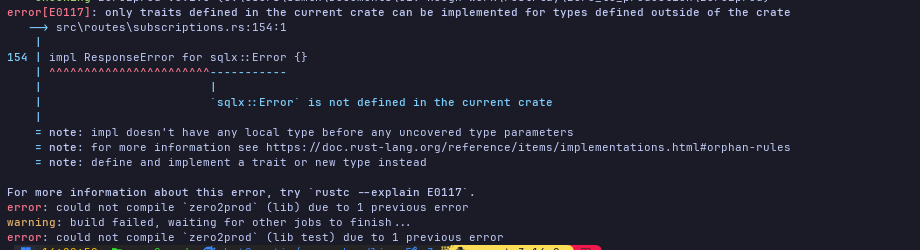

So what do we do now.  
The error returned gives us a hint
```bash
= note: define and implement a trait or new type instead
```

We create a new custom `StoreTokenError(sqlx::Error)` type that we can implement `ResponseError` for.  
```Rust
pub struct StoreTokenError(sqlx::Error);

impl ResponseError for StoreTokenError{}
```
Now we are good, right?  
Wrong.  
Why?  
Any trait that implemets `ResponseError` needs to also implement `std::fmt::Debug` and `std::fmt::Display` traits

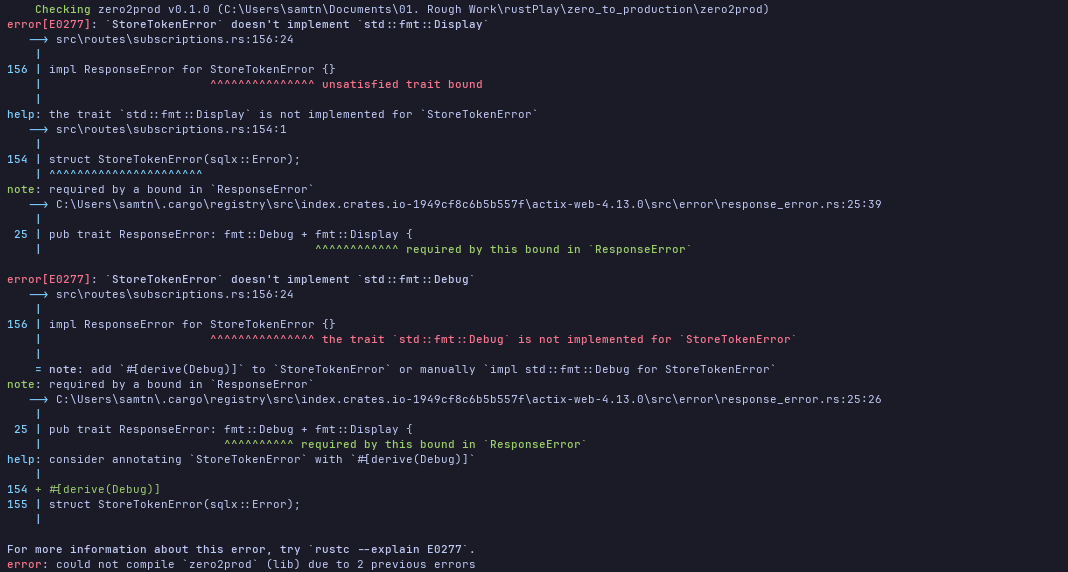

All right.  
```Rust
//! src/routes/subscriptions.rs
// [...]

#[derive(Debug)]
pub struct StoreTokenError(sqlx::Error);

impl std::fmt::Display for StoreTokenError 

    fn fmt(&self, f: std::fmt::Formatter<'_>) -> std::fmt::Result {
        write!(
            f,
            "A database error was encountered \
            while trying to store a subscription token"
        )
    }
    
}
```

Alright. We also need to ensure we've update `store_token` to return `StoreTokenError` in the `Err` variant of result instead of  
`sqlx::Error` right?  
Yup. 
Also we now need to update `subscribe` to return a result with an `actix_web::Error` variant in the result?  
Yup. You're getting the hang of it. Why do we need to do this?  
Because we ignored the propagated error before but now we want `subscribe` tracing instrumentation to be able to log the error with 
enough context from the underlying cause to know why we got `500 Intenal Server Error` if we encounter it.

Lets see what we now get in the logs.

```JSON
{
"timestamp": "2026-05-24T11:51:37.977814Z",
"level": "ERROR",
"fields": {
  "message": "Failed to execute store_token query: Database(PgDatabaseError { severity: Error, code: \"42703\", message: \"column \\\"subscription_token\\\" of relation \\\"subscription_tokens\\\" does not\nexist\", detail: None, hint: None, position: Some(Original(47)), where: None, schema: None, table: None, column: None, data_type: None, constraint: None, file: Some(\"parse_target.c\"), line: Some(1068), routine: Some(\"checkInsertTargets\") })"
},
"target": "zero2prod::routes::subscriptions",
"span": {
  "subscriber_email": "lei_yin_loo@gmail.com",
  "subscriber_username": "lei yin",
  "name": "Adding a new subscriber"
},
"spans": [
  {
    "http.client_ip": "127.0.0.1",
    "http.flavor": "1.1",
    "http.host": "127.0.0.1:55107",
    "http.method": "POST",
    "http.route": "/{name}",
    "http.scheme": "http",
    "http.target": "/subscriptions",
    "http.user_agent": "",
    "otel.kind": "server",
    "otel.name": "POST /{name}",
    "request_id": "97dd2498-6ae4-4446-85be-32879bbcbb2f",
    "name": "HTTP request"
  },
  {
    "subscriber_email": "lei_yin_loo@gmail.com",
    "subscriber_username": "lei yin",
    "name": "Adding a new subscriber"
  }
]
},
{
"timestamp": "2026-05-24T11:51:37.978681Z",
"level": "ERROR",
"fields": {
  "message": "Error encountered while processing the incoming HTTP request: StoreTokenError(Database(PgDatabaseError { severity: Error, code: \"42703\", message: \"column \\\"subscription_token\\\" of relation \\\"subscription_tokens\\\" does not exist\", detail: None, hint: None, position: Some(Original(47)), where: None, schema: None, table: None, column: None, data_type: None, constraint: None, file: Some(\"parse_target.c\"), line: Some(1068), routine: Some(\"checkInsertTargets\") }))"
},
"target": "tracing_actix_web::middleware",
"span": {
  "exception.details": "StoreTokenError(Database(PgDatabaseError { severity: Error, code: \"42703\", message: \"column \\\"subscription_token\\\" of relation \\\"subscription_tokens\\\" does not exist\", detail: None, hint: None, position: Some(Original(47)), where: None, schema: None, table: None, column: None, data_type: None, constraint: None, file: Some(\"parse_target.c\"), line: Some(1068), routine: Some(\"checkInsertTargets\") }))",
  "exception.message": "A database error was encountered when attempting to store a subscription token",
  "http.client_ip": "127.0.0.1",
  "http.flavor": "1.1",
  "http.host": "127.0.0.1:55107",
  "http.method": "POST",
  "http.route": "/{name}",
  "http.scheme": "http",
  "http.status_code": 500,
  "http.target": "/subscriptions",
  "http.user_agent": "",
  "otel.kind": "server",
  "otel.name": "POST /{name}",
  "otel.status_code": "ERROR",
  "request_id": "97dd2498-6ae4-4446-85be-32879bbcbb2f",
  "name": "HTTP request"
},
"spans": [
  {
    "exception.details": "StoreTokenError(Database(PgDatabaseError { severity: Error, code: \"42703\", message: \"column \\\"subscription_token\\\" of relation \\\"subscription_tokens\\\" does not exist\", detail: None, hint: None, position: Some(Original(47)), where: None, schema: None, table: None, column: None, data_type: None, constraint: None, file: Some(\"parse_target.c\"), line: Some(1068), routine: Some(\"checkInsertTargets\") }))",
    "exception.message": "A database error was encountered when attempting to store a subscription token",
    "http.client_ip": "127.0.0.1",
    "http.flavor": "1.1",
    "http.host": "127.0.0.1:55107",
    "http.method": "POST",
    "http.route": "/{name}",
    "http.scheme": "http",
    "http.status_code": 500,
    "http.target": "/subscriptions",
    "http.user_agent": "",
    "otel.kind": "server",
    "otel.name": "POST /{name}",
    "otel.status_code": "ERROR",
    "request_id": "97dd2498-6ae4-4446-85be-32879bbcbb2f",
    "name": "HTTP request"
  }
]
}
```

The key last JSON body is what we are looking for. Note that the HTTP request span is now appropriately populated.  
Actually this is something to note.

Previously the spans logged were as follows:
```JSON
"spans": [
  {
    "http.client_ip": "127.0.0.1",
    "http.flavor": "1.1",
    "http.host": "127.0.0.1:55107",
    "http.method": "POST",
    "http.route": "/{name}",
    "http.scheme": "http",
    "http.target": "/subscriptions",
    "http.user_agent": "",
    "otel.kind": "server",
    "otel.name": "POST /{name}",
    "request_id": "97dd2498-6ae4-4446-85be-32879bbcbb2f",
    "name": "HTTP request"
  },
  {
    "subscriber_email": "lei_yin_loo@gmail.com",
    "subscriber_username": "lei yin",
    "name": "Adding a new subscriber"
  }
]
```
Note that we have the _Http Request_ and the _Add a new subscriber_ span. We can see how the _Http Request_ span was shallow, not even including  
the target. This is of course because we were ignoring the underlying propagated issue.

The new logs are more informative and we can see even the target is populated for the _Http Request_ span and includes the status code, exception 
details and exception message.

```JSON
"target": "tracing_actix_web::middleware",
"span": {
  "exception.details": "StoreTokenError(Database(PgDatabaseError { severity: Error, code: \"42703\", message: \"column \\\"subscription_token\\\" of relation \\\"subscription_tokens\\\" does not exist\", detail: None, hint: None, position: Some(Original(47)), where: None, schema: None, table: None, column: None, data_type: None, constraint: None, file: Some(\"parse_target.c\"), line: Some(1068), routine: Some(\"checkInsertTargets\") }))",
  "exception.message": "A database error was encountered when attempting to store a subscription token",
  "http.client_ip": "127.0.0.1",
  "http.flavor": "1.1",
  "http.host": "127.0.0.1:55107",
  "http.method": "POST",
  "http.route": "/{name}",
  "http.scheme": "http",
  "http.status_code": 500,
  "http.target": "/subscriptions",
  "http.user_agent": "",
  "otel.kind": "server",
  "otel.name": "POST /{name}",
  "otel.status_code": "ERROR",
  "request_id": "97dd2498-6ae4-4446-85be-32879bbcbb2f",
  "name": "HTTP request"
}
```

### 8.2.2. The Error Trait

#### 8.2.2.1. Overview and Trait Objects

##### 8.2.2.0. Deep Dive: Summarize, ELI5, Connect

There's a couple of things we want to cover in this section.
1. Establishing why implementing the `std::error::Error` trait is necessary for our custom errors
    - We look at the default implementation
2. Understand a little around trait objects
3. We then implement `Error` on `StoreTokenError`
4. Implement a custom `Debug` `fmt` function for `StoreTokenError` for explicitly communicating how its related to the `sqlx::Error` it wraps.
5. We add `err_fmt_source` and update our `Debug` trait implementation for `StoreToken` 

_**Summarize**_  
_So what is the need of implementing the `std::error::Error` trait on our custom errors_?  
It provides the correct semmantics for someone to immedately reason about our error type in that
1. We are providing the different representations (Debug and Display) tuned for different audiences
2. We provide a straight forward way to look at the underlying cause behind and error, if any using `Error::source`

_Ok. But why does it return a [trait object](https://doc.rust-lang.org/book/ch18-02-trait-objects.html)?_ `Option<(dyn Error + 'static)>`
While trait objects do incur a runtime cost becuase they are resolved at runtime through dynamic dispatch, they provide a opaque access
to the error without leaking type information about the underlying issue. Which is what we want. We don't want to be leaking out implementation  
details to non operators.

The `Error` trait does allow us to downcast to a specific type if needed, but this should be used sparingly.

#### 8.2.2.2. `Error::source`

The `Error` trait exposes a `source` method by which we can access one level deeper in the **error chain**.
```Rust
pub trait Error: Debug + Display {
    // The lower-level source of this error, if any
    fn source(&self) -> Option<(dyn Error + 'static)> {
        None
    }
}
```

Alright then. Lets go ahead an implement `Error` for `StoreTokenError`.  
```Rust
//! src/routes/subscriptions.rs
// [...]

#[derive(Debug)]
struct StoreTokenError(sqlx::Error);

impl std::error::Error for StoreTokenError {
    fn source(&self) -> Option<(dyn Error + 'static)> {
        Some(&self.0)
    }
}
```

This works. However we imply that the `StoreTokenError` is cause the `sqlx::Error`, and it doesn't really differ from the logs we had before

Lets be more explicit by defining a custom implementation of the `Debug` trait and customize the messaging.
```Rust
//! src/routes/subscriptions.rs
// [...]

// We remove the default Debug derivation for a custom one
struct StoreTokenError(sqlx::Error);

// Custom Debug trait implementaiton
impl Debug for StoreTokenError {
    fn fmt(&self, f: &mut std::fmt::Formatter<'_>) -> std::fmt::Result {
        write!(f, "{}\nCaused by:\n{}", self, self.0)
    }
}

impl std::error::Error for StoreTokenError {
    fn source(&self) -> Option<(dyn Error + 'static)> {
        Some(&self.0)
    }
}
```

We know have a more explicit `exception.detail` value compared to what we had initially.
```JSON
{
    // ...
  "target": "tracing_actix_web::middleware",
  "span": {
    "exception.details": "A database error was encountered when attempting to store a subscription token.\nCaused by:\nerror returned from database: column \"subscription_token\" of relation \"subscription_tokens\" does not exist",
    "exception.message": "A database error was encountered when attempting to store a subscription token",
    // ..
  },
  "spans": [
    {
        // ..
    }
  ]
}
```

We also want away to go down the error chain if say we encounter errors that go deeper than just one level.
```Rust
//! src/routes/subscriptions.rs
// [...]

struct StoreTokenError(sqlx::Error);

impl Debug for StoreTokenError {
    fn fmt(&self, f: &mut std::fmt::Formatter<'_>) -> std::fmt::Result {
        err_fmt_source(self, f)
    }
}

impl Error for StoreTokenError {
    fn source(&self) -> Option<&(dyn Error + 'static)> {
        Some(&self.0)
    }
}

fn err_chain_format(
    e: &impl std::error::Error,
    f: &mut std::fmt::Formatter<'_>,
) -> std::fmt::Result {
    write!(f, "{}\n", e)?;
    let mut current = e.source();
    while let Some(cause) = current {
        write!(f, "Cause by:\n{}", cause)?;
        current = cause.cause();
    }
    Ok(())
}
```
In the `StoreTokenError` case, the error will be identical to the earlier one we just shared with the added benefit that we can reuse this function with other
errors as wells as the ability to iterate through the error chain until we get to the root cause of errors with more depth.

## 8.3. Errors For Control Flow

##### 8.3.0.0. Skimming: What did you notice and why? Any Questions

_**What?**_<br/>

- Implementing the `From` `Debug` and `Display` traits manually for our error enums.
- Seeing how `thiserror` makes this easier for us using procedural macros

_**Why?**_<br/>
- Helpful to see the internals of how `std` traits are implemented for our custom types

_**Questions?**_<br/>


##### 8.3.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
In this iteration the author notes that our current implementation, it is incorrect to implement `ResponseError` on `StoreTokenError` because it's the handler's work to determine what the resultant error code should be, based on the  
errors we encounter. Thus the more appropriate approach is to create a `SubscribeError` type that enumerates `StoreTokenError` as one if its variants. We iterate through implementing the `SubscribeError` enum from implementing
all the necessary errors manually and then using libraries such as `thiserror` first to simplify the implementation.

On a high level this is what we go through in this section.
1. In the first iteration we add the `SubscribeError` enum and its invariants
   ```Rust
   enum SubscribeError {
       ValidationError(String),
       DatabaseError(sqlx::Error),
       StoreTokenError(StoreTokenError),
       SendEmailError(reqwest::Error)
   }
   ```
2. We use the default `#[derive(Debug)]` on `SubscribeError` but implement the `Display` trait similar to what we had for `StoreTokenError`
3. We the implement the `From` trait for converting the errors we encounter into the enum variants we've defined
4. Next we implement the `ResponseError` trait on `SubscribeError` matching the variants to the appropriate status code
5. Add the appropriate `Display` trait implementations for the `SubscribeError` variants
6. We also implement the `Error` trait on `SubscribeError` and implement `source` to return the appropriate source for each variant.
7. Whe then update how we call the relevant methods on `subscribe` with the try `?` operator. Note that the error variant of `subscribe` needs to now be updated from `actix_web::Error` to `SubscribeError`
8. We take note that we are losing a bit of information when an error occurs at beginning a transaction, also at `insert_subscriber` and `transaction.commit` because we are
   using one error `DatabaseError` to represent them all. So we break it down into.
   - `PoolError`
   - `InsertSubscriberError`
   - `TransactionCommitError`
9. We then need to update the `ResponseError` implementation to return the appropriate status code
10. We also need to account for the new variants in the `Error` implementations of `source`
11. We also need to update the `Display` implementation of `fmt` for each variant
11. We then need to `map_err` for the specific relevant calls in `subscribe` because we can't do a straight forward converstion using `From<sqlx::Error>` because it is ambiguos on which variant we can encounter.
12. We then introduce `thiserror` that simplyfies our implementaiton

### 8.3.1. Layering

Here the author recommends separation of concerns where `subscribe` is responsible for deciding the appropriate response for a propagated error and what to include in the logs.  
This is instead of the underlying error itself determining the error response. The book goes through first implementing a `SubscribeError` as a struct the implementing
all the required trait.  

I however will jump straight into the enum implementation and add the required traits.

### 8.3.2. Modelling Errors As Enums

This first iteration of `SubscribeError` enumarates the errors we are likely to encounter in `subscribe` and implements `From` , `Display` trait  
and proceed with the default `ResponseError` and `Error` trait implementation.

```Rust
//! src/routes/subscriptions.rs
// [...]

#[tracing::instrumct(/**/)]
pub async fn subscribe(/**/) -> Result<HttpResponse, SubscribeError> {
    let new_subscriber = form.0.try_into()?;
    let mut transaction = db_pool.begin().await?;
    let subscriber_id = insert_subscriber(&mut transaction, &new_subscriber).await?;
    let subscriptionb_token = generate_subscription_token();
    store_token(&mut transaction, &subscription_token, subscriber_id).await?;
    transaction.commit().await?
    send_confirmation_email(&email_client, new_subscriber, &base_url.0, &subscription_token).await?;
    // [...]
}

#[derive(Debug)]
enum SubscribeError {
    ValidationError(String),
    DatabaseError(sqlx::Error),
    StoreTokenError(StoreTokenError),
    SendEmailError(reqwest::Error),
}

impl std::fmt::Display for SubscribeError {
    fn fmt(&self, f: &mut std::fmt::Formatter<'_>) -> std::fmt::Result {
        write!(f, "Failed to add new subscriber")
    }
}

impl std::error::Error for SubscribeError {}
impl ResponseError for SubscribeError {}

impl From<String> for SubscribeError {
    fn from(e: String) -> Self {
        Self::ValidaitonError(e)
    }
}

impl From<sqlx::Error> for SubscribeError {
    fn from(e: sqlx::Error) -> Self {
        Self::DatabaseError(e)
    }
}

impl From<StoreTokenError> for SubscribeError {
    fn from(e: StoreTokenError) -> Self {
        Self::ValidaitonError(e)
    }
}

impl From<reqwest::Error> for SubscribeError {
    fn from(e: reqwest::Error) -> Self {
        Self::ValidaitonError(e)
    }
}

```

With this in place, when we run our tests, we get the folling error  
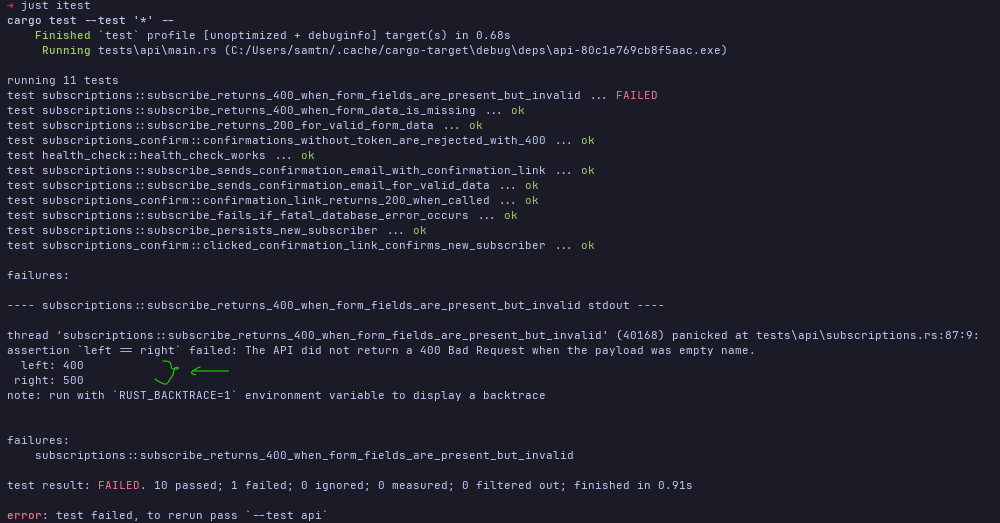

To address this we need to implement a custom `status_code` for the `ResponseError` trait for each variant of `SubscribeError`
```Rust
//! src/routes/subscriptions.rs
// [...]

impl ResponseError for SubscriptionError {
    fn status_code(&self) -> StatusCode {
        match self {
            SubscriptionError::ValidationError(_) => StatusCode::BAD_REQUEST,
            SubscriptionError::DatabaseError(_) 
            | SubscriptionError::StoreTokenError(_) 
            | SubscriptionError::SendEmailError(_) => StatusCode::INTERNAL_SERVER_ERROR,
        }
    }
}

// [...]
```

After this, out test suite should pass again

### 8.3.3. The Error Type Is Not Enough

What does this mean? _The Error Type is not Enough_.

I think in general it means that we might be missing some key error modes that are not represented.

I think it means 2 things
1. The `error_message` now only uses the message from the global `impl std::fmt:::Display for SubscribeErrorr`, which means we are losing some contextual
    info on the error variants

   ```json
     {
      "timestamp": "2026-05-29T07:15:03.854000Z",
      "level": "ERROR",
      "fields": {
        "message": "Error encountered while processing the incoming HTTP request: StoreToken(A database error was encountered when attempting to store a subscription token.\n\nCause by:\n\terror returned from database: column \"subscription_token\" of relation \"subscription_tokens\" does not existCause by:\n\tcolumn \"subscription_token\" of relation \"subscription_tokens\" does not exist)"
      },
      "target": "tracing_actix_web::middleware",
      "span": {
        "exception.details": "StoreToken(A database error was encountered when attempting to store a subscription token.\n\nCause by:\n\terror returned from database: column \"subscription_token\" of relation \"subscription_tokens\" does not existCause by:\n\tcolumn \"subscription_token\" of relation \"subscription_tokens\" does not exist)",
        "exception.message": "Failed to insert new subscriber", // < --- HERE
        "http.client_ip": "127.0.0.1",
        "http.flavor": "1.1",
        "http.host": "127.0.0.1:52651",
        "http.method": "POST",
        "http.route": "/{name}",
        "http.scheme": "http",
        "http.status_code": 500,
        "http.target": "/subscriptions",
        "http.user_agent": "",
        "otel.kind": "server",
        "otel.name": "POST /{name}",
        "otel.status_code": "ERROR",
        "request_id": "bce5c3d1-674c-45c3-8374-ecb86b422bfd",
        "name": "HTTP request"
      },
      "spans": [
        {
          "exception.details": "StoreToken(A database error was encountered when attempting to store a subscription token.\n\nCause by:\n\terror returned from database: column \"subscription_token\" of relation \"subscription_tokens\" does not existCause by:\n\tcolumn \"subscription_token\" of relation \"subscription_tokens\" does not exist)",
          "exception.message": "Failed to insert new subscriber", // < --- HERE
          "http.client_ip": "127.0.0.1",
          "http.flavor": "1.1",
          "http.host": "127.0.0.1:52651",
          "http.method": "POST",
          "http.route": "/{name}",
          "http.scheme": "http",
          "http.status_code": 500,
          "http.target": "/subscriptions",
          "http.user_agent": "",
          "otel.kind": "server",
          "otel.name": "POST /{name}",
          "otel.status_code": "ERROR",
          "request_id": "bce5c3d1-674c-45c3-8374-ecb86b422bfd",
          "name": "HTTP request"
        }
      ]
    }
   ```
2. The `DatabaseError` type is ambigous because it might be as a caused by
    - an error in obtaining a connection to the database pool to begin a transaction
    - an error when inserting a subsciber
    - an error when committing a transaction.  
    
   So we need a to add the enum variants to represents these potential failure modes.

After these changes we need to update `subscribe` with `map_err` for the relevant methods.

Below is how we go about resolving the above gaps
```Rust
//! src/routes/subscriptions.rs
// [...]

pub enum SubscribeError {
    ValidationError(String),
    PoolError(sqlx::Error),
    InsertSubscriberError(sqlx::Error),
    StoreTokenError(StoreTokenError),
    TransactionCommitError(sqlx::Error)
    SendEmailError(reqwest::Error),
}

impl std::fmt::Display for SubscribeError {
    fn fmt(&self, f: &mut std::fmt::Formatter<'_>) -> std::fmt::Result {
        match self {
            SubscribeError::ValidationError(e) => write!(f, "{}", e),
            SubscribeError::PoolError(e) => write!(f, "Failed to acquire a Postgres connection from the pool."),
            SubscribeError::InsertSubscriberError(e) => write!(f, "Failed to insert a new subscriber to database."),
            SubscribeError::StoreTokenError(e) => write!(f, "Failed to store the confirmation subscription token for a new subscriber."),
            SubscribeError::TransactionCommit(e) => write!(f, "Failed to commit SQL transaction to store a new subscriber."),
            SubscribeError::SendEmailError(e) => write!(f, "Failed to send confirmation email."),
        }
    }
}

impl std::fmt::Debug for SubscribeError {
    fn fmt(&self, f: &mut std::fmt::Formatter<'_>) -> std::fmt::Result {
        error_chain_fmt(self, f);
    }
}

impl ResponseError for SubscribeError {
    fn status_code(&self) -> StatusCode {
        match self {
            SubscribeError::ValidationError(_) => StatusCode::BAD_REQUEST,
            SubscribeError::PoolError(_)
            | SubscribeError::InsertSubscriberError(_)
            | SubscribeError::StoreTokenError(_)
            | SubscribeError::TransactionCommmit(_)
            | SubscribeError::SendEmailError(_) => StatusCode::INTERNAL_SERVER_ERROR,
        }
    }
}

impl std::error::Error for SubscribeError {
    fn source(&self) -> Option<&(dyn Error + 'static)> {
        match &self {
            SubscribeError::ValidationError(_) => None,
            SubscribeError::PoolError(e) => Some(e),
            SubscribeError::InsertSubscriberError(e) => Some(e),
            SubscribeError::StoreTokenError(e) => Some(e),
            SubscribeError::TransactionCommitError(e) => Some(e),
            SubscribeError::SendEmailError(e) => Some(e),
        }
    }
}

#[tracing::instrument(/**/)]
pub async fn subscribe(/**/) -> Result<HttpResponse, SubscribeError> {
    let new_subscriber = form.0.try_into()?;
    let mut transaction =  db_pool.begin().await.map_err(SubscribeError::PoolError)?;
    let subscriber_id = insert_subscriber(/**/).await.map_err(SubscribeError::InsertSubscriberError)?;
    let subscription_token = generate_subscription_token();
    store_token(/**/).await?;
    transaction.commit().await.map_err(SubscribeError::TransactionCommitError)?;
    send_confirmation_email(/**/).await?;
}
```

We also remove the `Form<sqlx::Error> for SubscribeError` implementation for `Subscribe::DatabaseError`.

The logs should now be adding the useful `exception.message` appropriate for the encountered error.  

```JSON
{
  "timestamp": "2026-05-30T04:36:16.738971Z",
  "level": "ERROR",
  "fields": {
    "message": "Error encountered while processing the incoming HTTP request: Failed to store confirmation token for a new subscriber.\n\nCause by:\n\tA database error was encountered when attempting to store a subscription token.Cause by:\n\terror returned from database: column \"subscription_token\" of relation \"subscription_tokens\" does not existCause by:\n\tcolumn \"subscription_token\" of relation \"subscription_tokens\" does not exist"
  },
  "target": "tracing_actix_web::middleware",
  "span": {
    "exception.details": "Failed to store confirmation token for a new subscriber.\n\nCause by:\n\tA database error was encountered when attempting to store a subscription token.Cause by:\n\terror returned from database: column \"subscription_token\" of relation \"subscription_tokens\" does not existCause by:\n\tcolumn \"subscription_token\" of relation \"subscription_tokens\" does not exist",
    "exception.message": "Failed to store confirmation token for a new subscriber.",
    "http.client_ip": "127.0.0.1",
    "http.flavor": "1.1",
    "http.host": "127.0.0.1:63169",
    "http.method": "POST",
    "http.route": "/{name}",
    "http.scheme": "http",
    "http.status_code": 500,
    "http.target": "/subscriptions",
    "http.user_agent": "",
    "otel.kind": "server",
    "otel.name": "POST /{name}",
    "otel.status_code": "ERROR",
    "request_id": "15ea41f4-dc67-459c-813a-e6ee8e9a5850",
    "name": "HTTP request"
  },
  "spans": [
    {
      "exception.details": "Failed to store confirmation token for a new subscriber.\n\nCause by:\n\tA database error was encountered when attempting to store a subscription token.Cause by:\n\terror returned from database: column \"subscription_token\" of relation \"subscription_tokens\" does not existCause by:\n\tcolumn \"subscription_token\" of relation \"subscription_tokens\" does not exist",
      "exception.message": "Failed to store confirmation token for a new subscriber.",
      "http.client_ip": "127.0.0.1",
      "http.flavor": "1.1",
      "http.host": "127.0.0.1:63169",
      "http.method": "POST",
      "http.route": "/{name}",
      "http.scheme": "http",
      "http.status_code": 500,
      "http.target": "/subscriptions",
      "http.user_agent": "",
      "otel.kind": "server",
      "otel.name": "POST /{name}",
      "otel.status_code": "ERROR",
      "request_id": "15ea41f4-dc67-459c-813a-e6ee8e9a5850",
      "name": "HTTP request"
    }
  ]
}
```

### 8.3.4. Removing The Boilerplate With `thiserror`

_**Summary**_  
Here the main thing is leaning on the `thiserror` crate that removes the `Debug`, `Display` and `From` traits that we wrote by hand.

```Rust
#[derive(thiserror::Error)]
pub enum SubscribeError{
    #[error("{0}")]
    ValidationError(String),
    #[error("Failed to acquire Postgres connection to the pool.")]
    PoolError(#source sqlx::Error)
    #[error("Failed to insert a new subscriber to the database.")]
    InsertSubscriberError(#source sqlx::Error)
    #[error("Failed to store confirmation token for a new subscriber.")]
    StoreTokenError(#from StoreTokenError)
    #[error("Failed to commit SQL transaction for persisting a new subscriber.")]
    TransactionCommit(#source sqlx::Error)
    #[error("Failed to send confirmation email.")]
    SendEmailError(#from reqwest::Error)
}
```

With this in place we can nuke the `Debug`, `Display` & `From` trait implementations on `SubscribeError`.

`thiserror::Error` is a procedural macro that we use with `#[derive(this::Error)]` and it takes in as input `SubscribeError` and returns as a 
stream of token as output (_it generates rust code_) that is compiled into the final binary. With it we get the following 3 annotations with their  
uses
- `#[error(/**/)]` - That implements the `Display` trait for the variant it is applied to. We provide the contextual message for the error here.
  In the case of `VaidationError` we use `#[error("{0}")]` following the tuple struct definiation of the `String` to be extracted out here.
- `#source` - implements the `Error::source` for the variant it is applied to and whatever proceeds it is denotated as the source or the error
- `#from` - implements the `From` trait for conversion as well as `Error::source`

Also we need to apply `map_err` for the `ValidationError` because `Error` trait cannot be implemented for `&str` and that why we returned `None`.

## 8.4. Avoid "Ball Of Mud" Error Enums

##### 8.1.2.1.0 Skimming: What did you notice and why? Any Questions

_**What?**_<br/>

- We get to see why and where we would use the `anyhow` trait.


_**Why?**_<br/>

- Clears a misconception I had earlier by stating that `thiserror` for libraries and `anyhow` for
  applictions is  not the right framing, as we need to reason about intent.

  If the intent is to be able to respond differently to different errors and give the caller maximum flexibilty to be able to deal/respond with
  different errors accordingly and programmatically we should use `thiserror`

  If instead we just want the user to be informed of something that failed without needed an operator or user to respond programmatically use `anyhow`.
  Makes the crate names stand out a bit more
  - "_Deal with_ `thiserror`"
  - "`anyhow` _this error occurred_"

   <br/>

  For example i'm thinking a _retriable_ error is a good candidate for `thiserror` because we can deal with it programmatically. However something
  like a database failure there is no way to deal with it programmatically we have to get into the code and debug what went wrong and fix it. This is
  where `anyhow` comes in?

_**Questions?**_<br/>



### 8.4.0. Overview

### 8.4.1. Using `anyhow` As An Opaque Error Type

### 8.4.2. `anyhow` Or `thiserror`?

## 8.5. Who Should Log Errors?

##### 8.1.2.1.0 Skimming: What did you notice and why? Any Questions

_**What?**_<br/>

- The author says a good rule of thumb is to log errors where they are handle. Indicating that if we are using the try operator `?`
  for propagating errors to callers, we should not be logging.


_**Why?**_<br/>

- Curious how the callers should log it? Should we, at the call sight then use `.map_err(|e| {tracing::error!("...{}", e); e})` and
  remove it from the propagator?

_**Questions?**_<br/>
The ones stated above.


## 8.6. Summary

##### 8.1.2.1.0 Skimming: What did you notice and why? Any Questions

_**What?**_<br/>

- Implementing error handling on the `confirm` handler is left as an exercise to the reader. 

_**Why?**_<br/>

- Like this

_**Questions?**_<br/>
None